# JAE: Joint Autoencoder Demo

Demonstrates neural signal denoising using JAE (Altan et al., 2021).


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import torch

from jae import JAE, simulate_neural_data, calculate_vaf, run_pca_baseline, set_seed

set_seed(42)
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

%matplotlib inline
plt.rcParams['figure.dpi'] = 100


PyTorch: 2.8.0+cu128
CUDA available: True


## Generate Simulated Data

Following the paper's methodology (Fig 1):
- Sample latent signals from Poisson-like distribution
- Smooth with Gaussian kernel
- Linear mixing via random matrix
- Optional exponential nonlinearity (Eq 1)
- Add Gaussian noise with specified SNR


In [ ]:
# Generate data with moderate noise (5 dB SNR)
clean, noisy, info = simulate_neural_data(
    n_samples=300,
    n_channels=96,
    n_timepoints=128,
    latent_dim=6,
    snr_db=5.0,
    nonlinear=True,
    seed=42
)

print(f"Shape: {noisy.shape}")
print(f"SNR: {info['snr_db']:.1f} dB")


Data shape: torch.Size([500, 96, 128])
Actual SNR: 5.7 dB
Latent dim: 6


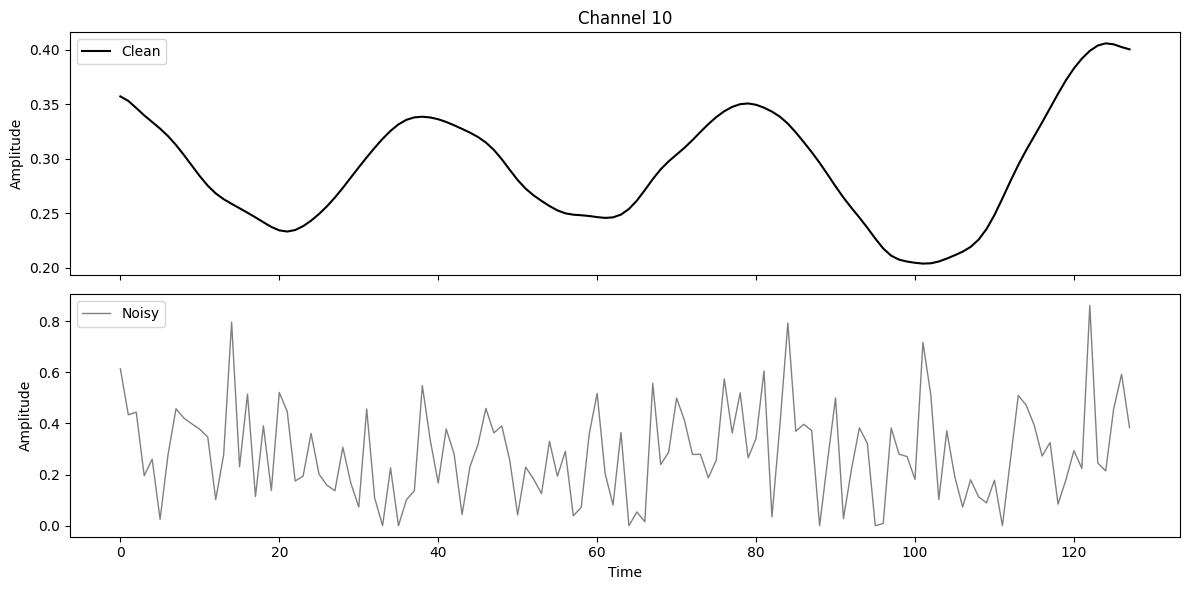

In [3]:
# Visualize example signals
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

sample_idx, ch = 0, 10
t = np.arange(clean.shape[2])

axes[0].plot(t, clean[sample_idx, ch, :], 'k', lw=1.5, label='Clean')
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Channel {ch}')
axes[0].legend()

axes[1].plot(t, noisy[sample_idx, ch, :], 'gray', lw=1, label='Noisy')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time')
axes[1].legend()

plt.tight_layout()
plt.show()


## Train JAE

Using the original paper's architecture (default settings).


In [ ]:
# Train JAE (latent_dim=8, slightly larger than true dim for robustness)
model = JAE(latent_dim=8, verbose=True)
model.fit(noisy.numpy(), epochs=300, batch_size=32)


Using device: cuda (NVIDIA GeForce RTX 4090, 24.0 GB)
Initialized JAE (original mode):
  Input channels: 96
  Latent dimension: 6

Training for 100 epochs...
Epoch 1/100, Loss: 0.2621
Epoch 10/100, Loss: 0.1524
Epoch 20/100, Loss: 0.1401
Epoch 30/100, Loss: 0.1387
Epoch 40/100, Loss: 0.1370
Epoch 50/100, Loss: 0.1364
Epoch 60/100, Loss: 0.1343
Epoch 70/100, Loss: 0.1339
Epoch 80/100, Loss: 0.1335
Epoch 90/100, Loss: 0.1332
Epoch 100/100, Loss: 0.1326
Training complete.


In [ ]:
# Denoise and get PCA baseline
denoised = torch.from_numpy(model.denoise(noisy.numpy()))
pca_denoised = run_pca_baseline(noisy, latent_dim=8)


## Evaluate: VAF (Variance Accounted For)

The paper uses VAF (R²) as the primary metric for denoising quality.


In [ ]:
# Compute VAF
vaf_noisy = calculate_vaf(clean, noisy)
vaf_pca = calculate_vaf(clean, pca_denoised)
vaf_jae = calculate_vaf(clean, denoised)

print("Variance Accounted For (VAF):")
print(f"  Noisy: {vaf_noisy:.3f}")
print(f"  PCA:   {vaf_pca:.3f}")
print(f"  JAE:   {vaf_jae:.3f}")

if vaf_jae > vaf_pca:
    print(f"\n✓ JAE beats PCA by {vaf_jae - vaf_pca:.3f}")
else:
    print(f"\n✗ PCA wins by {vaf_pca - vaf_jae:.3f}")


Variance Accounted For (VAF):
  Noisy:    -0.211
  PCA:      0.902
  JAE:      -0.387

Reconstruction Error (1 - VAF):
  Noisy:    1.211
  PCA:      0.098
  JAE:      1.387


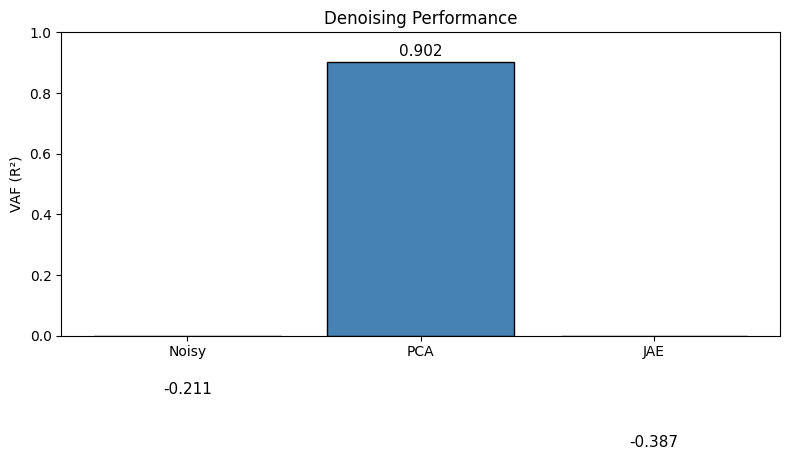

In [7]:
# Bar plot comparison
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['Noisy', 'PCA', 'JAE']
vafs = [vaf_noisy, vaf_pca, vaf_jae]
colors = ['gray', 'steelblue', 'coral']

bars = ax.bar(methods, vafs, color=colors, edgecolor='black')
ax.set_ylabel('VAF (R²)')
ax.set_title('Denoising Performance')
ax.set_ylim(0, 1)

for bar, v in zip(bars, vafs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()


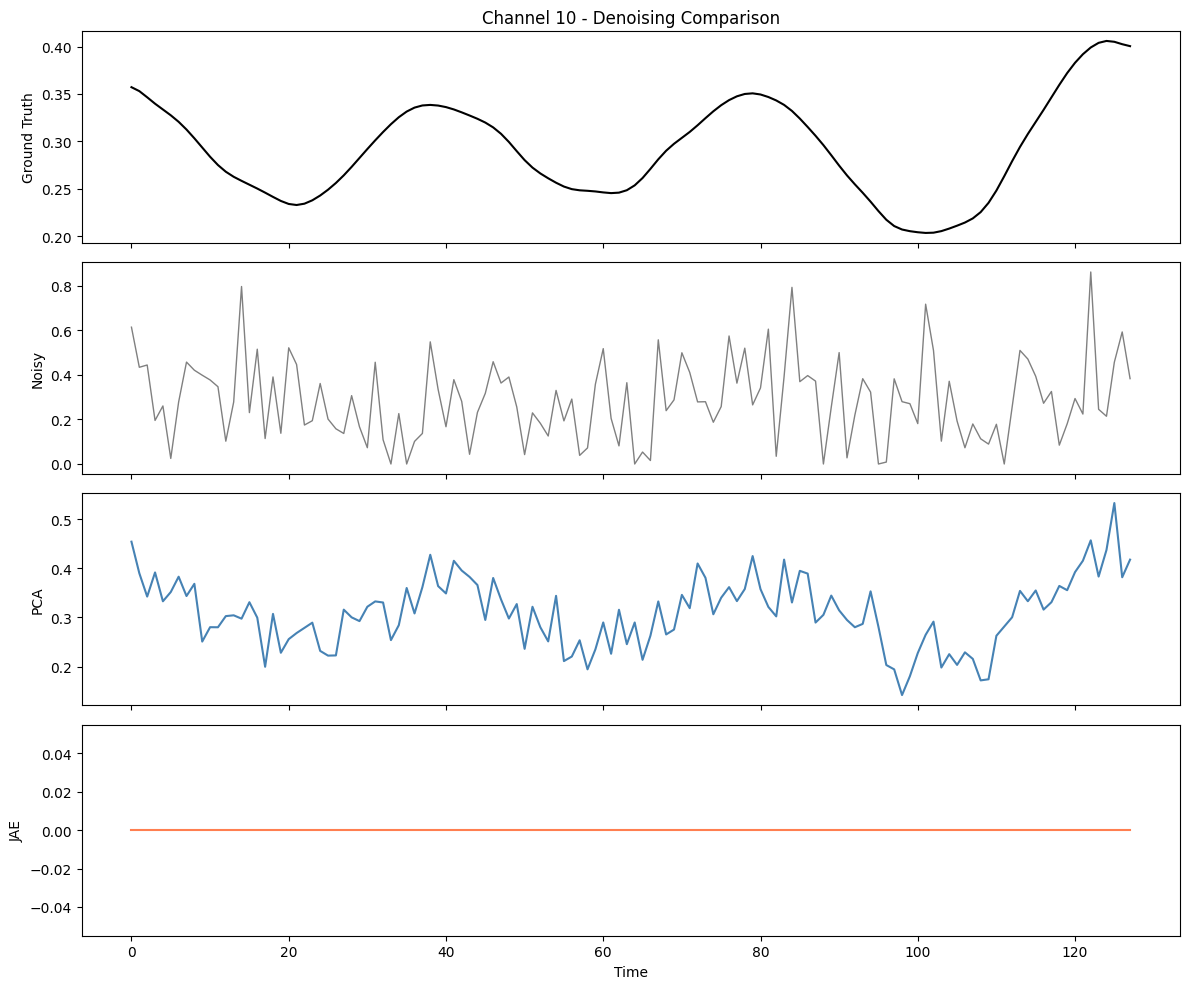

In [8]:
# Visual comparison
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

sample_idx, ch = 0, 10
t = np.arange(clean.shape[2])

axes[0].plot(t, clean[sample_idx, ch, :], 'k', lw=1.5)
axes[0].set_ylabel('Ground Truth')
axes[0].set_title(f'Channel {ch} - Denoising Comparison')

axes[1].plot(t, noisy[sample_idx, ch, :], 'gray', lw=1)
axes[1].set_ylabel('Noisy')

axes[2].plot(t, pca_denoised[sample_idx, ch, :], 'steelblue', lw=1.5)
axes[2].set_ylabel('PCA')

axes[3].plot(t, denoised[sample_idx, ch, :], 'coral', lw=1.5)
axes[3].set_ylabel('JAE')
axes[3].set_xlabel('Time')

plt.tight_layout()
plt.show()


## Test with Different SNR Levels


In [ ]:
snr_levels = [0, 3, 5, 10]
results = {'SNR': [], 'PCA': [], 'JAE': []}

for snr in snr_levels:
    print(f"SNR={snr}dB...", flush=True)
    clean, noisy, _ = simulate_neural_data(
        n_samples=200, snr_db=snr, nonlinear=True, seed=42
    )
    
    model = JAE(latent_dim=8, verbose=False)
    model.fit(noisy.numpy(), epochs=200, batch_size=32, verbose=False)
    denoised = torch.from_numpy(model.denoise(noisy.numpy()))
    pca_denoised = run_pca_baseline(noisy, latent_dim=8)
    
    results['SNR'].append(snr)
    results['PCA'].append(calculate_vaf(clean, pca_denoised))
    results['JAE'].append(calculate_vaf(clean, denoised))
    
    print(f"  PCA={results['PCA'][-1]:.3f}, JAE={results['JAE'][-1]:.3f}")

print("Done!")


SNR = 0 dB...
SNR = 3 dB...
SNR = 5 dB...
SNR = 10 dB...
SNR = 15 dB...
Done!


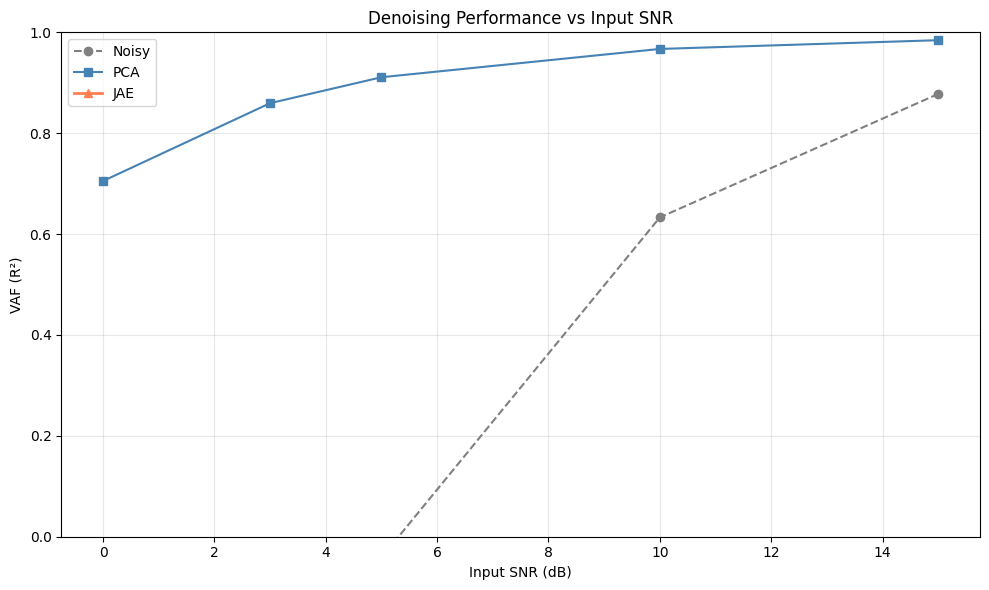

In [ ]:
# Plot results
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(results['SNR'], results['PCA'], 's-', label='PCA', color='steelblue', lw=2)
ax.plot(results['SNR'], results['JAE'], '^-', label='JAE', color='coral', lw=2)

ax.set_xlabel('Input SNR (dB)')
ax.set_ylabel('VAF (R²)')
ax.set_title('Denoising Performance vs SNR')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()
